DATASET principal data (kaggle hackaton:)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa



In [43]:

# Base folder that contains class subfolders (asthma, copd, etc.)
base_data_dir = Path("data")

label_map = {
    "asthma": "Asthma",
    "copd": "COPD",
    "bronchial": "Bronchial",
    "pneumonia": "Pneumonia",
    "healthy": "Healthy",
}

rows = []

for wav_path in base_data_dir.rglob("*.wav"):
    folder_name = wav_path.parent.name.lower()
    label = label_map.get(folder_name, wav_path.parent.name)

    with contextlib.closing(wave.open(str(wav_path), "rb")) as wav_file:
        sample_rate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        duration_sec = n_frames / float(sample_rate) if sample_rate else 0.0

    # Relative path inside the stage after PUT data/*.wav @audio_stage
    file_path = str(wav_path.as_posix())

    rows.append(
        {
            "file_name": wav_path.name,
            "label": label,
            "duration_sec": duration_sec,
            "sample_rate": sample_rate,
            "file_path": file_path,
        }
    )

df = pd.DataFrame(rows).sort_values(["label", "file_name"]).reset_index(drop=True)
df


,file_name,label,duration_sec,sample_rate,file_path
0,P10AsthmaIE_49.wav,Asthma,3.136000,4000,data/asthma/P10AsthmaIE_49.wav
1,P10AsthmaIU_46.wav,Asthma,4.944000,4000,data/asthma/P10AsthmaIU_46.wav
2,P10AsthmaIU_50.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaIU_50.wav
3,P10AsthmaRL_47.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaRL_47.wav
4,P10AsthmaRS_48.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaRS_48.wav
...,...,...,...,...,...
1206,P9Pneumonia63O.wav,Pneumonia,4.922154,44100,data/pneumonia/P9Pneumonia63O.wav
1207,P9Pneumonia67I.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia67I.wav
1208,P9Pneumonia73J.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia73J.wav
1209,P9Pneumonia74S.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia74S.wav


Dataset data2 (Chest Wall Lung Sound Dataset)

In [44]:
from pathlib import Path
import pandas as pd
import re
import wave
import contextlib

def extract_label_from_filename(filename: str):
    name = Path(filename).stem
    name = re.sub(r"^BP\d+_", "", name, flags=re.IGNORECASE)
    return name.split(",")[0].strip()

rows = []

base_dir = Path("data_2")

for wav_path in base_dir.rglob("*.wav"):
    label = extract_label_from_filename(wav_path.name)

    # lecture rapide sans librosa (plus léger)
    with contextlib.closing(wave.open(str(wav_path), "rb")) as f:
        sr = f.getframerate()
        n_frames = f.getnframes()
        duration = n_frames / float(sr) if sr else 0

    rows.append({
        "file_name": wav_path.name,
        "label_raw": label,
        "duration_sec": duration,
        "sample_rate": sr,
        "path": str(wav_path)
    })

df_data2 = pd.DataFrame(rows)
df_data2.head()



,file_name,label_raw,duration_sec,sample_rate,path
0,"DP93_N,N,P R M,75,M.wav",DP93_N,9.840,4000,"data_2/Audio Files/DP93_N,N,P R M,75,M.wav"
1,"BP53_asthma,E W,P R M,72,F.wav",asthma,8.688,4000,"data_2/Audio Files/BP53_asthma,E W,P R M,72,F.wav"
2,"EP108_COPD,E W,P R L ,63,M.wav",EP108_COPD,22.832,4000,"data_2/Audio Files/EP108_COPD,E W,P R L ,63,M.wav"
3,"BP70_N,N,P L U,52,F.wav",N,13.744,4000,"data_2/Audio Files/BP70_N,N,P L U,52,F.wav"
4,"EP32_N,N,A R L,30,M.wav",EP32_N,18.352,4000,"data_2/Audio Files/EP32_N,N,A R L,30,M.wav"


On normalise + regroupe les labels


In [45]:
df_data2['sample_rate'].value_counts()

sample_rate
4000    336
Name: count, dtype: int64

In [63]:
df_data2["label_raw"].value_counts().head(30)

label_raw
N                                    35
Asthma                               17
asthma                               15
heart failure                        15
COPD                                  8
pneumonia                             5
Lung Fibrosis                         4
Heart Failure                         3
BRON                                  3
Heart Failure + COPD                  2
Plueral Effusion                      2
DP93_N                                1
EP108_COPD                            1
EP32_N                                1
EP80_asthma                           1
DP75_N                                1
EP54_heart failure                    1
Heart Failure + Lung Fibrosis         1
DP69_pneumonia                        1
EP26_Lung Fibrosis                    1
DP53_asthma                           1
EP51_N                                1
DP97_Asthma                           1
DP12_Asthma                           1
EP28_BRON                     

In [53]:
def clean_label(label):
    label = label.lower()

    # enlever préfixes type dp35_, ep14_
    label = re.sub(r"^[a-z]{1,3}\d+_", "", label)

    # enlever espaces
    label = label.strip()

    if "asthma" in label:
        return "Asthma"
    elif label == "copd":
        return "COPD"
    elif label == "pneumonia":
        return "Pneumonia"
    elif label in ["n", "normal"]:
        return "Healthy"
    elif label.startswith("bron"):
        return "Bronchial"
    else:
        return "Other"

    



df_data2["label_clean"] = df_data2["label_raw"].apply(clean_label)
df_data2["label_clean"].value_counts().head(20)

label_clean
Healthy      105
Asthma        99
Other         81
COPD          27
Pneumonia     15
Bronchial      9
Name: count, dtype: int64

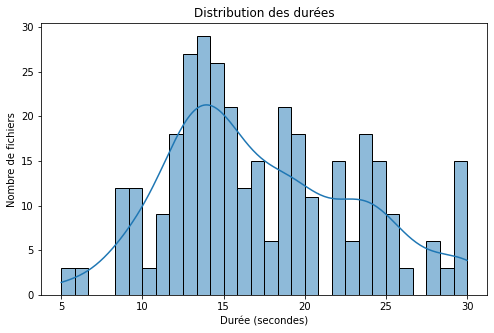

'\nplt.figure(figsize=(10, 4))\n        librosa.display.waveshow(y, sr=sr)\n        plt.ylim(-global_max_abs, global_max_abs)\n        plt.title(f"Waveform - {category_name}")\n        plt.xlabel("Time (s)")\n        plt.ylabel("Amplitude")\n        plt.tight_layout()\n        plt.show()'

In [54]:
plt.figure(figsize=(8, 5))
sns.histplot(df_data2["duration_sec"], bins=30, kde=True)
plt.title("Distribution des durées")
plt.xlabel("Durée (secondes)")
plt.ylabel("Nombre de fichiers")
plt.show()

'''
plt.figure(figsize=(10, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.ylim(-global_max_abs, global_max_abs)
        plt.title(f"Waveform - {category_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()'''

On vérifie que les données ne sont pas les mêmes et que notre nouveau dataset est un vrai ajour pertinent

In [55]:
set_df = set(df["file_name"])
set_data2 = set(df_data2["file_name"])

common_files = set_df.intersection(set_data2)

print(f"Nombre de fichiers communs : {len(common_files)}")

Nombre de fichiers communs : 0


In [56]:
df_merge = df.merge(
    df_data2,
    on=["duration_sec", "sample_rate"],
    how="inner",
    suffixes=("_df", "_data2")
)

len(df_merge)

9

In [49]:
import hashlib

def hash_audio(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
    
df["hash"] = df["file_path"].apply(hash_audio)
df_data2["hash"] = df_data2["path"].apply(hash_audio)

common_hashes = set(df["hash"]).intersection(set(df_data2["hash"]))

print(f"Nombre de vrais doublons audio : {len(common_hashes)}")

Nombre de vrais doublons audio : 2


In [50]:
def get_mfcc_signature(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfcc, axis=1)  # signature compacte

def similarity(sig1, sig2):
    return np.linalg.norm(sig1 - sig2)


sig_data = [get_mfcc_signature(p) for p in df["file_path"][:50]]
sig_data2 = [get_mfcc_signature(p) for p in df_data2["path"][:50]]

for i, s1 in enumerate(sig_data):
    for j, s2 in enumerate(sig_data2):
        if similarity(s1, s2) < 5:  # seuil à ajuster
            print("Possible overlap:", i, j)


Possible overlap: 2 5
Possible overlap: 3 1
Possible overlap: 46 27


On prépare data2 pour le merger à data

In [57]:
df_data2_filtered = df_data2[df_data2["label_clean"] != "Other"].copy()
print(df_data2_filtered["label_clean"].value_counts())

label_clean
Healthy      105
Asthma        99
COPD          27
Pneumonia     15
Bronchial      9
Name: count, dtype: int64


### STANDARDISATION


In [58]:
import hashlib
import numpy as np

def hash_standardized_audio(y: np.ndarray) -> str:
    y = np.asarray(y, dtype=np.float32)
    return hashlib.md5(y.tobytes()).hexdigest()

In [59]:
import librosa
import numpy as np
import os

TARGET_SR      = 22050   # sample rate cible
TARGET_DURATION = 6.0    # secondes
TARGET_LEN     = int(TARGET_SR * TARGET_DURATION)  # = 132 300 samples

def load_and_standardize(filepath):
    # Chargement + resampling automatique vers 22050 Hz
    y, sr = librosa.load(filepath, sr=TARGET_SR, mono=True)

    # Trop long → on tronque
    if len(y) > TARGET_LEN:
        y = y[:TARGET_LEN]

    # Trop court → on padde avec des zéros (silence)
    elif len(y) < TARGET_LEN:
        y = np.pad(y, (0, TARGET_LEN - len(y)), mode='constant')

    # Normalisation amplitude entre -1 et 1
    max_val = np.abs(y).max()
    if max_val > 0:
        y = y / max_val

    return y  # shape garantie : (132300,)

In [71]:
def load_and_standardize2(filepath, segment_duration=6.0, target_sr=22050):
    y, sr = librosa.load(filepath, sr=target_sr, mono=True)

    segment_len = int(segment_duration * target_sr)
    segments = []

    n_segments = len(y) // segment_len

    for i in range(n_segments):
        start = i * segment_len
        end = start + segment_len
        seg = y[start:end]

        max_val = np.abs(seg).max()
        if max_val > 0:
            seg = seg / max_val

        segments.append(seg.astype(np.float32))

    return segments

On standardise et on hashe data

In [89]:
df_std = df.copy()

df_std["audio_std"] = df_std["file_path"].apply(load_and_standardize)
df_std["std_hash"] = df_std["audio_std"].apply(hash_standardized_audio)

print(df_std.head())

            file_name   label  duration_sec  sample_rate  \
0  P10AsthmaIE_49.wav  Asthma         3.136         4000   
1  P10AsthmaIU_46.wav  Asthma         4.944         4000   
2  P10AsthmaIU_50.wav  Asthma         6.000         4000   
3  P10AsthmaRL_47.wav  Asthma         6.000         4000   
4  P10AsthmaRS_48.wav  Asthma         6.000         4000   

                        file_path                              hash  \
0  data/asthma/P10AsthmaIE_49.wav  6eda4f488a51a556cb288870865a399e   
1  data/asthma/P10AsthmaIU_46.wav  c5daf126e96933feac0075993dc5cc33   
2  data/asthma/P10AsthmaIU_50.wav  fde234dada2e70a1497b2bd828628390   
3  data/asthma/P10AsthmaRL_47.wav  1e8bbdaa265bfabc3591c9c969f6f2fa   
4  data/asthma/P10AsthmaRS_48.wav  affa44ed00c7c3276d97598aebee9a86   

                                           audio_std  \
0  [0.08356565, 0.09709146, 0.10254319, 0.1008565...   
1  [0.27037022, 0.31450987, 0.3327289, 0.32801682...   
2  [-2.458824e-07, -5.1411774e-07, -7.152942

In [90]:
df_std["std_len"] = df_std["audio_std"].apply(len)
df_std["std_duration_sec"] = df_std["std_len"] / TARGET_SR
df_std["std_sample_rate"] = TARGET_SR

print(df_std[[
    "file_name", "duration_sec", "sample_rate",
    "std_len", "std_duration_sec", "std_sample_rate"
]].head())

            file_name  duration_sec  sample_rate  std_len  std_duration_sec  \
0  P10AsthmaIE_49.wav         3.136         4000   132300               6.0   
1  P10AsthmaIU_46.wav         4.944         4000   132300               6.0   
2  P10AsthmaIU_50.wav         6.000         4000   132300               6.0   
3  P10AsthmaRL_47.wav         6.000         4000   132300               6.0   
4  P10AsthmaRS_48.wav         6.000         4000   132300               6.0   

   std_sample_rate  
0            22050  
1            22050  
2            22050  
3            22050  
4            22050  


On va standardiser et hasher data2, en en profitant pour segmenter les fichiers de 30 secondes et ainsi gagner de la data

In [ ]:
rows = []

for _, row in df_data2_filtered.iterrows():
    segments = load_and_standardize2(row["path"])

    for seg_idx, seg in enumerate(segments):
        rows.append({
            "source_file": row["file_name"],
            "label": row["label_clean"],
            "segment_index": seg_idx,
            "audio_std": seg,
            "std_hash": hash_standardized_audio(seg),
            "std_len": len(seg),
            "std_duration_sec": len(seg) / TARGET_SR,
            "std_sample_rate": TARGET_SR,
            "path": row["path"],
        })

df_data2_segments = pd.DataFrame(rows)

                        file_name label_clean  duration_sec  sample_rate  \
0         DP93_N,N,P R M,75,M.wav     Healthy         9.840         4000   
1  BP53_asthma,E W,P R M,72,F.wav      Asthma         8.688         4000   
2  EP108_COPD,E W,P R L ,63,M.wav        COPD        22.832         4000   
3         BP70_N,N,P L U,52,F.wav     Healthy        13.744         4000   
4         EP32_N,N,A R L,30,M.wav     Healthy        18.352         4000   

                           std_hash  
0  f4a88ec7a34ff5cdc896745e9a82a1c5  
1  b51048f587f903a55f95080b25ed2bec  
2  ebfce7db7f3f21dd4cc8b1c858cd7420  
3  dd40b1ae04b919e158642a272c43155b  
4  d4014ba0c8770c9f1c68ba2e9a8857eb  


In [79]:
df_data2_segments["label"].value_counts().head(20)

label
Healthy      272
Asthma       237
COPD          63
Pneumonia     42
Bronchial     15
Name: count, dtype: int64

In [80]:
print(df_data2_segments.head())


                      source_file    label  segment_index  \
0         DP93_N,N,P R M,75,M.wav  Healthy              0   
1  BP53_asthma,E W,P R M,72,F.wav   Asthma              0   
2  EP108_COPD,E W,P R L ,63,M.wav     COPD              0   
3  EP108_COPD,E W,P R L ,63,M.wav     COPD              1   
4  EP108_COPD,E W,P R L ,63,M.wav     COPD              2   

                                           audio_std  \
0  [-4.945674e-06, -3.0984945e-06, 2.5324235e-07,...   
1  [-8.322791e-07, -1.1790621e-06, -1.3611232e-06...   
2  [-2.3127914e-06, -2.4275057e-06, -9.2881703e-0...   
3  [0.1445876, 0.14448991, 0.14438364, 0.1442652,...   
4  [-0.45523164, -0.45546725, -0.45546156, -0.455...   

                           std_hash  std_len  std_duration_sec  \
0  f4a88ec7a34ff5cdc896745e9a82a1c5   132300               6.0   
1  b51048f587f903a55f95080b25ed2bec   132300               6.0   
2  0058ab3a98ec867398b096e6ad625135   132300               6.0   
3  a4c3fa95f74a3bc7c20bdee510821

In [91]:
print(df_std.head())


            file_name   label  duration_sec  sample_rate  \
0  P10AsthmaIE_49.wav  Asthma         3.136         4000   
1  P10AsthmaIU_46.wav  Asthma         4.944         4000   
2  P10AsthmaIU_50.wav  Asthma         6.000         4000   
3  P10AsthmaRL_47.wav  Asthma         6.000         4000   
4  P10AsthmaRS_48.wav  Asthma         6.000         4000   

                        file_path                              hash  \
0  data/asthma/P10AsthmaIE_49.wav  6eda4f488a51a556cb288870865a399e   
1  data/asthma/P10AsthmaIU_46.wav  c5daf126e96933feac0075993dc5cc33   
2  data/asthma/P10AsthmaIU_50.wav  fde234dada2e70a1497b2bd828628390   
3  data/asthma/P10AsthmaRL_47.wav  1e8bbdaa265bfabc3591c9c969f6f2fa   
4  data/asthma/P10AsthmaRS_48.wav  affa44ed00c7c3276d97598aebee9a86   

                                           audio_std  \
0  [0.08356565, 0.09709146, 0.10254319, 0.1008565...   
1  [0.27037022, 0.31450987, 0.3327289, 0.32801682...   
2  [-2.458824e-07, -5.1411774e-07, -7.152942

In [93]:
print(df_std.shape)
print(df_data2_segments.shape)



(1211, 11)
(629, 9)


In [94]:
print(df_std["std_len"].value_counts().head())
print(df_data2_segments["std_len"].value_counts().head())

std_len
132300    1211
Name: count, dtype: int64
std_len
132300    629
Name: count, dtype: int64


## On vérifie que le contenu de data et data2 est bien différent

In [95]:
common_hashes = set(df_std["std_hash"]).intersection(set(df_data2_segments["std_hash"]))
print("Nombre de doublons exacts :", len(common_hashes))

Nombre de doublons exacts : 0


# Waveform

In [100]:
from pathlib import Path
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def show_waveform_examples_data(base_data_dir="data", index=0, categories=None, standardize_fn=None):
    base_data_dir = Path(base_data_dir)

    if categories is None:
        categories = ["asthma", "bronchial", "copd", "healthy", "pneumonia"]

    category_dirs = [base_data_dir / category for category in categories]

    print("\n=== Waveform examples for data ===")
    loaded_waveforms = []

    for category_dir in category_dirs:
        if not category_dir.exists():
            print(f"Folder not found: {category_dir}")
            continue

        wav_files = sorted(category_dir.glob("*.wav"))
        if not wav_files:
            print(f"No .wav file in: {category_dir}")
            continue

        if index >= len(wav_files):
            print(f"Index {index} out of range for {category_dir.name}")
            continue

        audio_path = wav_files[index]

        if standardize_fn is None:
            y, sr = librosa.load(str(audio_path), sr=None)
        else:
            y = standardize_fn(str(audio_path))
            sr = TARGET_SR

        loaded_waveforms.append((category_dir.name, audio_path.name, y, sr))

    if not loaded_waveforms:
        print("No waveform could be loaded.")
        return

    global_max_abs = max(float(np.max(np.abs(y))) for _, _, y, _ in loaded_waveforms)
    if global_max_abs == 0.0:
        global_max_abs = 1.0

    for category_name, file_name, y, sr in loaded_waveforms:
        plt.figure(figsize=(10, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.ylim(-global_max_abs, global_max_abs)
        plt.title(f"Waveform - {category_name} - {file_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()

In [101]:
def show_waveform_examples_data2(df_data2_filtered, index=0, labels=None, standardize_fn=None):
    if labels is None:
        labels = ["Asthma", "Bronchial", "COPD", "Healthy", "Pneumonia"]

    print("\n=== Waveform examples for data2 ===")
    loaded_waveforms = []

    for label in labels:
        subset = df_data2_filtered[df_data2_filtered["label_clean"] == label]

        if subset.empty:
            print(f"No file found for label: {label}")
            continue

        subset = subset.sort_values("file_name").reset_index(drop=True)

        if index >= len(subset):
            print(f"Index {index} out of range for label {label}")
            continue

        row = subset.iloc[index]
        audio_path = row["path"]

        if standardize_fn is None:
            y, sr = librosa.load(audio_path, sr=None)
        else:
            y = standardize_fn(audio_path)
            sr = TARGET_SR

        loaded_waveforms.append((label, row["file_name"], y, sr))

    if not loaded_waveforms:
        print("No waveform could be loaded.")
        return

    global_max_abs = max(float(np.max(np.abs(y))) for _, _, y, _ in loaded_waveforms)
    if global_max_abs == 0.0:
        global_max_abs = 1.0

    for label, file_name, y, sr in loaded_waveforms:
        plt.figure(figsize=(10, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.ylim(-global_max_abs, global_max_abs)
        plt.title(f"Waveform - {label} - {file_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()


=== Waveform examples for data ===
Folder not found: data/bronchial


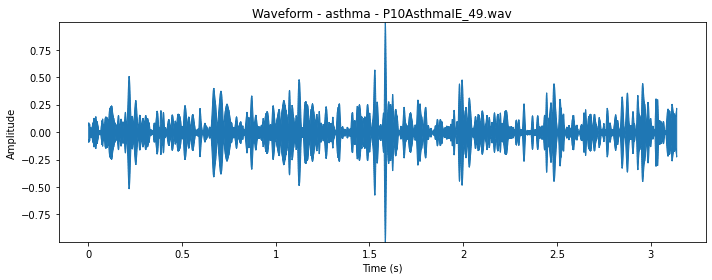

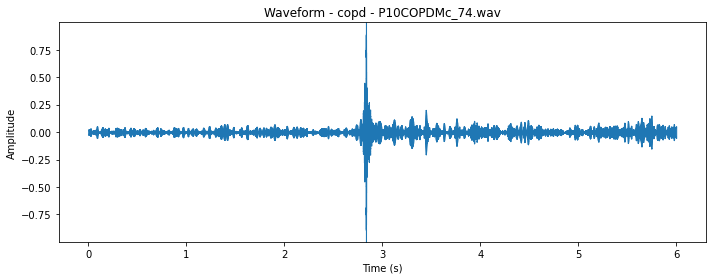

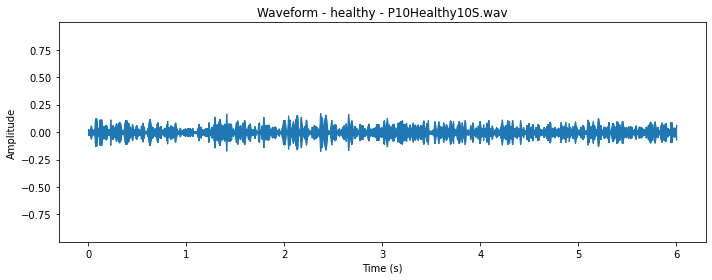

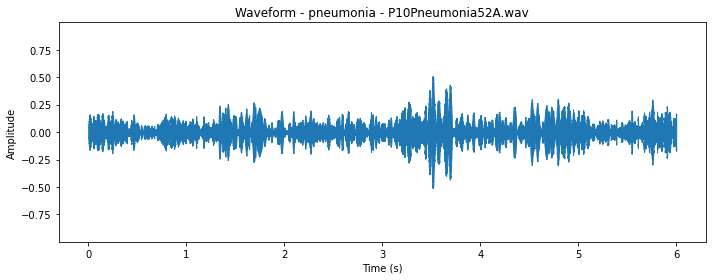

In [103]:
show_waveform_examples_data(base_data_dir="data")


=== Waveform examples for data ===
Folder not found: data/bronchial


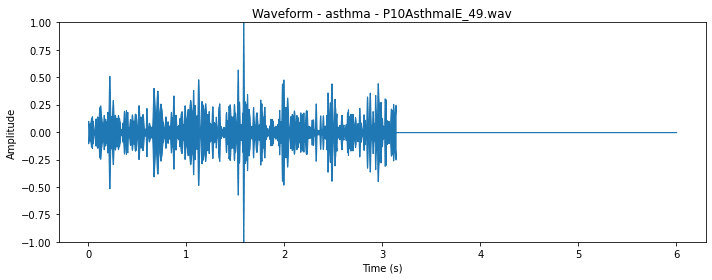

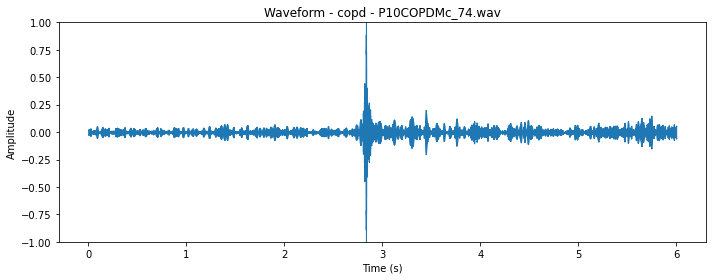

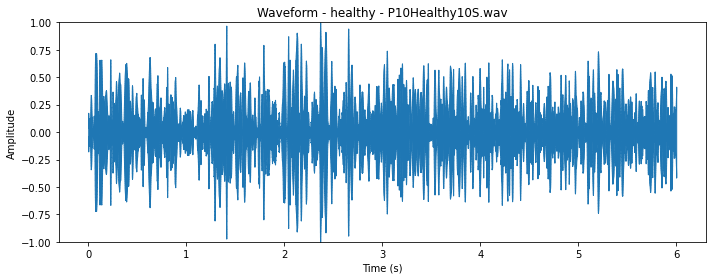

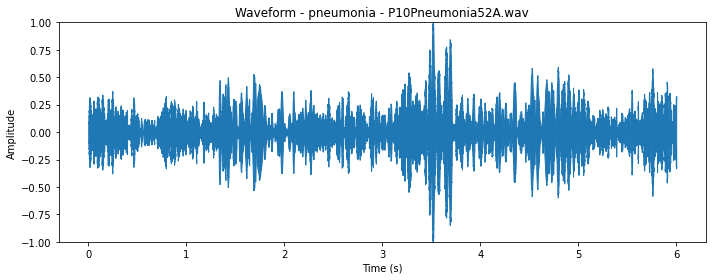

In [102]:
show_waveform_examples_data(
    base_data_dir="data",
    standardize_fn=load_and_standardize
)


=== Waveform examples for data2 ===


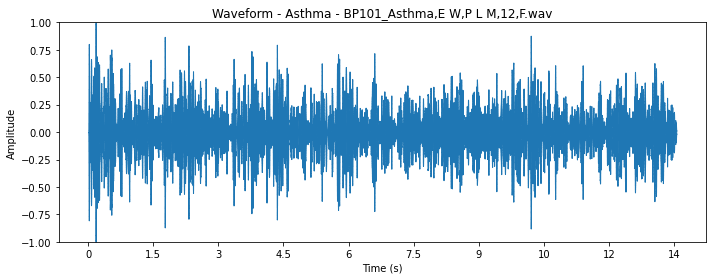

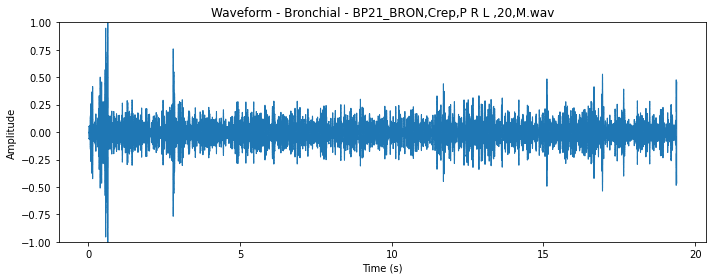

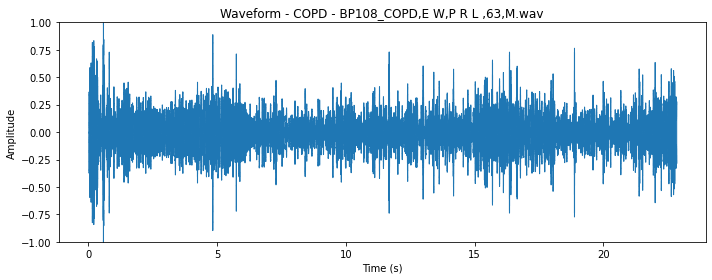

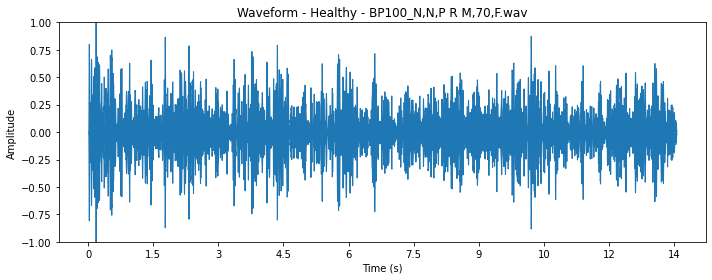

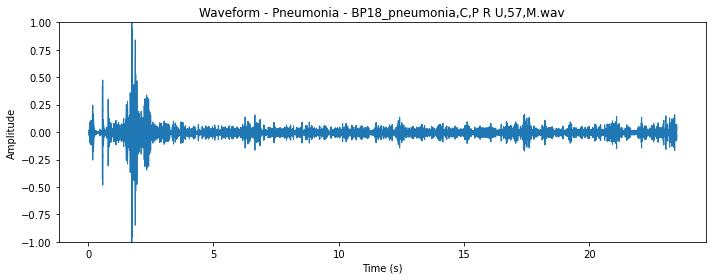

In [104]:
show_waveform_examples_data2(df_data2_filtered)